First 5 rows of the reduced dataset:
        PC1       PC2
0 -1.619530  0.450950
1 -0.799170  1.856553
2 -0.748479  0.882039
3  2.357673 -0.269976
4 -1.619530  0.450950

------------------------------

Explained Variance Ratio:
[0.28173931 0.1750827 ]

------------------------------



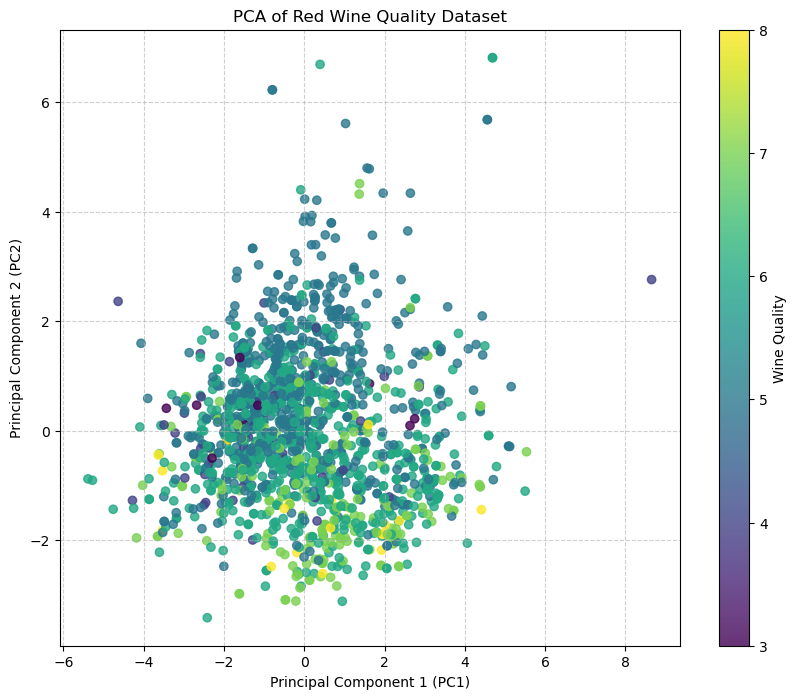

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("winequality-red.csv")

X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
print("First 5 rows of the reduced dataset:")
print(df_pca.head())
print("\n" + "-"*30 + "\n")

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("\n" + "-"*30 + "\n")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=y, 
    cmap='viridis',
    alpha=0.8
)

plt.colorbar(scatter, label='Wine Quality')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA of Red Wine Quality Dataset")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the data
df = pd.read_csv("winequality-red.csv")

# 2. Separate features (X) and target (y)
X = df.drop('quality', axis=1)
y = df['quality']

# 3. Create the scaler and define X_scaled!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. NOW you can safely train the PCA model
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Success! Both X_scaled and pca are now in memory.")

Success! Both X_scaled and pca are now in memory.


In [ ]:
import pickle

# Changed PCA to pca, and made the filename lowercase
with open('pca_model.pkl', 'wb') as file:
    pickle.dump(pca, file)
    
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [10]:
import pickle

# This will now work because the file actually has data in it
with open('pca_model.pkl', 'rb') as file:
    loaded_pca = pickle.load(file)